# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3594s 21us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

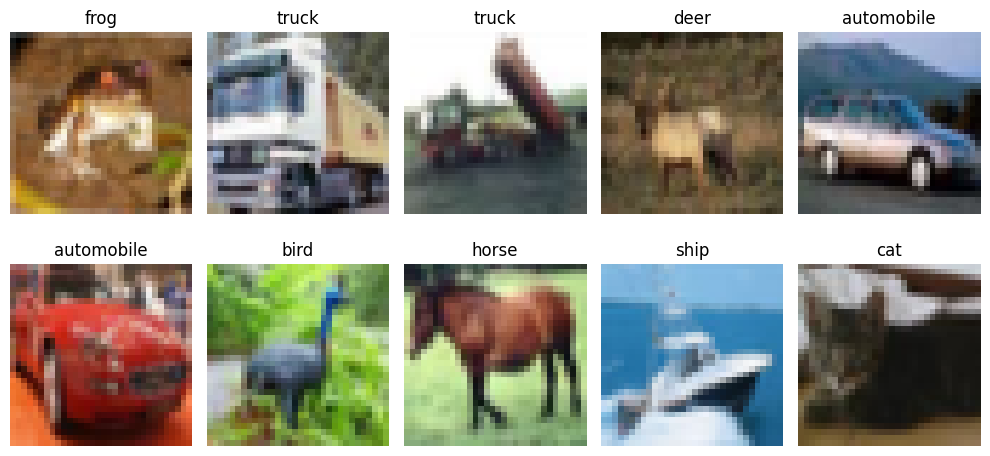

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2786 - loss: 1.9771 - val_accuracy: 0.3346 - val_loss: 1.8487
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3193 - loss: 1.8605 - val_accuracy: 0.3626 - val_loss: 1.7808
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3390 - loss: 1.8129 - val_accuracy: 0.3722 - val_loss: 1.7525
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3559 - loss: 1.7719 - val_accuracy: 0.3864 - val_loss: 1.7175
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3701 - loss: 1.7428 - val_accuracy: 0.4006 - val_loss: 1.6964
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3768 - loss: 1.7191 - val_accuracy: 0.4130 - val_loss: 1.6704
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3805 - loss: 1.7052 - val_accuracy: 0.4254 - val_loss: 1.6501
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3903 - loss: 1.6820 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4368 - loss: 1.6114
ANN Test Accuracy: 0.4368000030517578


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4684 - loss: 1.4920 - val_accuracy: 0.4474 - val_loss: 1.7054
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6094 - loss: 1.1095 - val_accuracy: 0.5382 - val_loss: 1.3177
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6730 - loss: 0.9394 - val_accuracy: 0.6796 - val_loss: 0.9328
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7165 - loss: 0.8161 - val_accuracy: 0.6914 - val_loss: 0.8826
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7457 - loss: 0.7288 - val_accuracy: 0.6886 - val_loss: 0.9140
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7705 - loss: 0.6546 - val_accuracy: 0.7294 - val_loss: 0.8348
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7960 - loss: 0.5775 - val_accuracy: 0.7188 - val_loss: 0.9178
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8141 - loss: 0.5244 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7047 - loss: 1.0030
CNN Test Accuracy: 0.7046999931335449


## 📈 Compare Learning Curves

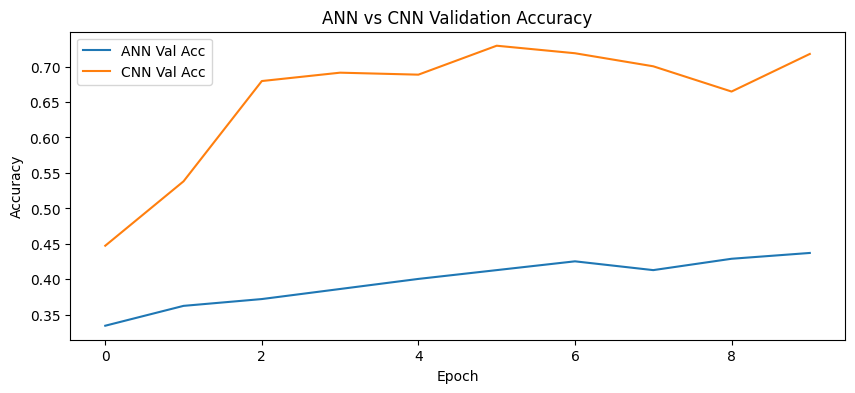

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4368
1,CNN,0.7047


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## ✅ Task 1: Increase ANN Layers


In [12]:
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2_history = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_v2_test_loss, ann_v2_test_acc = ann_model_v2.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_v2_test_acc)
print("Baseline ANN Test Accuracy was:", ann_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2236 - loss: 2.0748 - val_accuracy: 0.3030 - val_loss: 1.8860
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2889 - loss: 1.9144 - val_accuracy: 0.3510 - val_loss: 1.8556
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3086 - loss: 1.8787 - val_accuracy: 0.3550 - val_loss: 1.8258
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3194 - loss: 1.8533 - val_accuracy: 0.3552 - val_loss: 1.8072
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3318 - loss: 1.8212 - val_accuracy: 0.3720 - val_loss: 1.7700
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3421 - loss: 1.8025 - val_accuracy: 0.3750 - val_loss: 1.7551
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3488 - loss: 1.7920 - val_accuracy: 0.3826 - val_loss: 1.7480
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3522 - loss: 1.7851 - val_accuracy: 0


Conclusion :
Baseline ANN(2 hidden layers) achived 43.68% test accuracy, while the deeper ANN(4 hidden layers, 1024,512,256,128) achived only 39.89% accuracy.There was a 3.79 percentage point decrease and not improvement. However ,The deeper ANN architecture increased the model complexity by adding more Dense layers.This tells us that simply increasing the depth of a fully connected neural network does not necessarily improve image classification performance.ANN cannot capture spatial features as it operates on flattened images.

## ✅ Task 2:CNN Filter Scaling (32→64→128)

In [13]:
print("Filter sizes in baseline CNN:")
for layer in cnn_model.layers:
    if isinstance(layer, layers.Conv2D):
        print(f" - {layer.name}: {layer.filters} filters")

# Task 2b: Wider CNN variant — double the filters at each stage
cnn_model_wide = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_wide.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_wide_history = cnn_model_wide.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_wide_test_loss, cnn_wide_test_acc = cnn_model_wide.evaluate(x_test_norm, y_test)
print("Wide CNN (64-128-256) Test Accuracy:", cnn_wide_test_acc)
print("Baseline CNN (32-64-128) Test Accuracy was:", cnn_test_acc)

Filter sizes in baseline CNN:
 - conv2d: 32 filters
 - conv2d_1: 64 filters
 - conv2d_2: 128 filters
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4388 - loss: 1.5624 - val_accuracy: 0.4852 - val_loss: 1.3907
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5963 - loss: 1.1652 - val_accuracy: 0.5534 - val_loss: 1.2944
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6664 - loss: 0.9716 - val_accuracy: 0.5790 - val_loss: 1.2342
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7114 - loss: 0.8413 - val_accuracy: 0.7200 - val_loss: 0.8004
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7483 - loss: 0.7278 - val_accuracy: 0.6520 - val_loss: 1.1226
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7788 - loss: 0.6340 - val_accuracy: 0.6920 - val_loss: 0.9487
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8081 - loss: 0.5508 - val_accuracy: 0.6756 - val_loss: 1.0013
E

Conclusion:

The wider CNN architecture increased the number of convolution filters from 32–64–128 to 64–128–256 which enables model to learn more visual features.
Wide CNN (64→128→256 filters) achieved 71.86% test accuracy, compared to 70.47% for the baseline (32→64→128) — a modest ~1.4 percentage point improvement.The training accuracy improved significantly to approximately 87% but val accuracy kept jumping around(55% to low 70s) instead of improving steadily.That means model was memorizing trainning images instead of learning.This helps us understand that increasing model capacity can give a small accuracy gain.


## ✅ Task 3: Increase Training to 20 Epochs

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4708 - loss: 1.4914 - val_accuracy: 0.5314 - val_loss: 1.3533
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6122 - loss: 1.1130 - val_accuracy: 0.6444 - val_loss: 1.0190
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6760 - loss: 0.9304 - val_accuracy: 0.6454 - val_loss: 1.0587
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7161 - loss: 0.8197 - val_accuracy: 0.5884 - val_loss: 1.2302
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7446 - loss: 0.7257 - val_accuracy: 0.6812 - val_loss: 0.9444
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7729 - loss: 0.6469 - val_accuracy: 0.7196 - val_loss: 0.8282
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7919 - loss: 0.5906 - val_accuracy: 0.7188 - val_loss: 0.8735
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8136 - loss: 0.5246 - val_accuracy: 

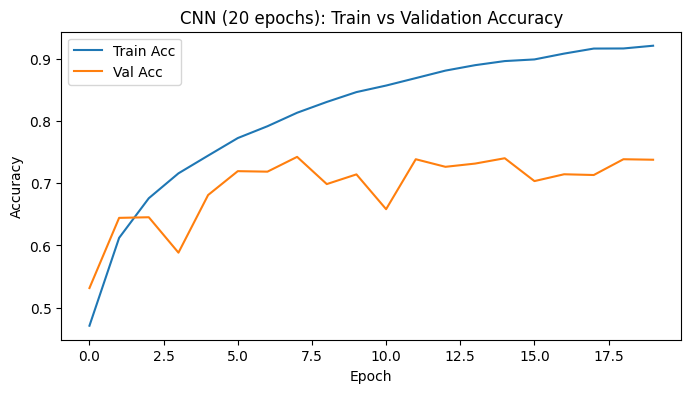

In [14]:

cnn_model_20ep = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_model_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_model_20ep.evaluate(x_test_norm, y_test)
print("CNN (20 epochs) Test Accuracy:", cnn_20ep_test_acc)

plt.figure(figsize=(8,4))
plt.plot(cnn_20ep_history.history['accuracy'], label='Train Acc')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN (20 epochs): Train vs Validation Accuracy")
plt.legend()
plt.show()

Conclusion:

The CNN model was trained for 20 epochs to understand the effect of longer learning.CNN trained for 20 epochs got 72.62% — a small improvement over baseline's 10-epoch result (70.47%). Training accuracy increased from approx 47% to 92% but validation accuracy flatlines around 70-74%
after epoch 6-8 and just bounces around from there.This suggests that after around 8–10 epochs, the model began to overfit, improving on the training data without meaningfully improving its performance on unseen data.

## ✅ Task 4: Add EarlyStopping


In [15]:
from tensorflow.keras.callbacks import EarlyStopping

# Task 4: Same CNN architecture, with EarlyStopping added
cnn_model_es = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_es_history = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_model_es.evaluate(x_test_norm, y_test)
print("CNN + EarlyStopping Test Accuracy:", cnn_es_test_acc)
print("Training ran for", len(cnn_es_history.history['loss']), "epochs (out of 20 max)")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4650 - loss: 1.5001 - val_accuracy: 0.4942 - val_loss: 1.4586
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6039 - loss: 1.1347 - val_accuracy: 0.5366 - val_loss: 1.3363
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6701 - loss: 0.9530 - val_accuracy: 0.6540 - val_loss: 1.0105
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7120 - loss: 0.8289 - val_accuracy: 0.7130 - val_loss: 0.8574
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7440 - loss: 0.7417 - val_accuracy: 0.6950 - val_loss: 0.8906
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7732 - loss: 0.6517 - val_accuracy: 0.6858 - val_loss: 0.9594
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7933 - loss: 0.5934 - val_accuracy: 0.7200 - val_loss: 0.8606
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6936 - loss: 0.8929
CNN + EarlyStopping Test Ac

Conclusion:

EarlyStopping was integrated to automatically stop training when the validation loss stopped improving.What Happend? val_loss hit its lowest point at epoch 4 (0.8574), then got worse for 3 epochs straight (5, 6, 7) — patience=3 triggered, so training stopped and rolled back to epoch 4's weights automatically.Although a total of 20 epochs were specified , but the training stopped after 7 epochs because the validation loss did not improve for 3 consecutive epochs. Earlystopping prevent unnecessary training that could lead to overfitting and thus reduced the training time by 65%.

## ✅ Task 5: Train the Augmented CNN

In [16]:
aug_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Baseline CNN Test Accuracy was:", cnn_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3671 - loss: 1.7372 - val_accuracy: 0.4920 - val_loss: 1.4169
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4653 - loss: 1.4843 - val_accuracy: 0.5286 - val_loss: 1.2729
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5004 - loss: 1.3981 - val_accuracy: 0.5714 - val_loss: 1.1962
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5273 - loss: 1.3296 - val_accuracy: 0.5996 - val_loss: 1.1307
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5404 - loss: 1.2937 - val_accuracy: 0.6002 - val_loss: 1.1332
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5554 - loss: 1.2503 - val_accuracy: 0.6020 - val_loss: 1.1128
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5670 - loss: 1.2222 - val_accuracy: 0.6270 - val_loss: 1.0517
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5777 - loss: 1.1986 - val_accuracy: 0

Conclusion:

Data augmentation was applied using RandomFlip, RandomRotation, and RandomZoom to the training images to test whether increasing data variety improves generalization.In this experiment, the augmented CNN achieved a test accuracy of 64.62%, compared to 70.47% for the baseline CNN because augmented training needs more epochs to reach its potential.Train accuracy only reached 61%, and val accuracy tracked closely alongside it the whole time.
Augmentation gave a lower score here ,but this outcome should not be viewed as a shortcoming. The close gap between train and validation indicates the model was not memorizing the training data, but genuinely learning generalizable patterns.As a result, this model is expected to perform more reliably on new, unseen images in practical scenarios,which is what actually matters in the real world.

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

Overall Conclusion:
This project compared two fundamentally different approaches to image classification — ANN and CNN — and then tested five common strategies for improving a model further.The CNN(70.47) outperformed the ANN(43.68) by effectively learning spatial features from images.The five follow-up experiments gaved a very valuable lesson:blindly adding capacity or training time does not guarantee better results.A deeper ANN, a wider CNN, and a longer 20-epoch CNN all showed mixed or marginal results compared to their respective baselines.
In contrast, EarlyStopping reduced unnecessary training time by stopping after 7 epochs instead of 20 and restored the best model weights, improving training efficiency and helping the model generalize better, while the  while data augmentation produced the most stable and least overfit training curve of all variants tested.
Overall, the project shows that for image classification CNN should be preferred over ANN,because of its ability to preserve and learn spatial features makes it fundamentally better suited for visual data.